# roll asset接入signals和portfolio示例

这份 notebook 展示一条最短可跑链路：

`generic contract market_data -> roll asset value_series -> signal -> portfolio weights`

目标不是做完整策略，而是帮助你确认：roll layer 生成的资产已经可以自然进入上层 `signals/portfolio` 工作流。


In [8]:
%matplotlib inline

from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path('/home/ubuntu/dengl/my_projects/cta_lab')
MARKET_DATA = ROOT.parent / 'market_data'

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import strategies.components.roll as roll_pkg
import strategies.components.roll.bundle as roll_bundle_mod
import strategies.components.roll.profile as roll_profile_mod
import signals as signals_pkg
import portfolio as portfolio_pkg

importlib.reload(roll_bundle_mod)
importlib.reload(roll_profile_mod)
importlib.reload(roll_pkg)
importlib.reload(signals_pkg)
importlib.reload(portfolio_pkg)

from strategies.components.roll import (
    BundleRollStrategy,
    BundleRule,
    ExecutionRuleConfig,
    LifecycleRuleConfig,
    MarketStateRuleConfig,
    RollComponentProfile,
    RollStrategyProfile,
    SelectorRuleConfig,
    build_single_asset_strategy_from_profile,
)
from signals import TSMOM, RankCombiner
from portfolio import EqualRiskSizer, RiskBudgetSizer, TopBottomSelector

plt.rcParams['figure.dpi'] = 120
ROOT, MARKET_DATA


(PosixPath('/home/ubuntu/dengl/my_projects/cta_lab'),
 PosixPath('/home/ubuntu/dengl/my_projects/market_data'))

## 1. 准备 helper：把 `market_data` 转成 single-asset roll 输入


In [9]:
def load_china_generic_contract_market_data(symbol: str, start=None, end=None, root: Path = MARKET_DATA) -> dict:
    contract_info_path = root / 'contracts' / 'china' / 'contract_info.parquet'
    kline_path = root / 'kline' / 'china_daily_full' / f'{symbol}.parquet'

    contracts = pd.read_parquet(contract_info_path)
    contracts = contracts.loc[contracts['fut_code'] == symbol].copy()
    contracts = contracts.rename(columns={
        'ts_code': 'contract_id',
        'list_date': 'list_date',
        'delist_date': 'last_trade_date',
    })
    contracts['list_date'] = pd.to_datetime(contracts['list_date'].astype(str), format='%Y%m%d')
    contracts['last_trade_date'] = pd.to_datetime(contracts['last_trade_date'].astype(str), format='%Y%m%d')
    contracts['last_holding_date'] = contracts['last_trade_date']
    contracts = contracts[['contract_id', 'list_date', 'last_trade_date', 'last_holding_date']].sort_values('contract_id')

    raw = pd.read_parquet(kline_path).copy()
    raw['trade_date'] = pd.to_datetime(raw['trade_date'])
    if start is not None:
        raw = raw.loc[raw['trade_date'] >= pd.Timestamp(start)]
    if end is not None:
        raw = raw.loc[raw['trade_date'] <= pd.Timestamp(end)]

    prices = raw.pivot(index='trade_date', columns='contract_code', values='close_price').sort_index()
    open_interest = raw.pivot(index='trade_date', columns='contract_code', values='interest').sort_index()

    keep_contracts = sorted(set(prices.columns) & set(contracts['contract_id']))
    contracts = contracts.loc[contracts['contract_id'].isin(keep_contracts)].reset_index(drop=True)
    prices = prices.reindex(columns=keep_contracts)
    open_interest = open_interest.reindex(columns=keep_contracts)

    return {
        'contracts': contracts,
        'prices': prices,
        'open_interest': open_interest,
    }


## 2. 先构造几个 single-asset roll asset

这里选 4 个国内商品：`CU / AL / RB / HC`。规则保持一致：
- `fixed_days_before_expiry`
- `field_max(open_interest)`
- `linear` 3 日展期
- `hybrid selector`


In [10]:
symbols = ['CU', 'AL', 'RB', 'HC']
single_asset_results = {}

for symbol in symbols:
    profile = RollStrategyProfile(
        name=f'{symbol.lower()}_single_asset',
        asset_key=symbol,
        lifecycle_rule_config=LifecycleRuleConfig(
            kind='fixed_days_before_expiry',
            params={'roll_days': 3, 'date_field': 'last_holding_date'},
        ),
        market_state_rule_config=MarketStateRuleConfig(
            kind='field_max',
            params={'field_name': 'open_interest'},
        ),
        execution_rule_config=ExecutionRuleConfig(
            kind='linear',
            params={'roll_days': 3},
        ),
        selector_rule_config=SelectorRuleConfig(kind='hybrid', params={}),
    )
    strategy = build_single_asset_strategy_from_profile(profile)
    market_data = load_china_generic_contract_market_data(symbol, start='2022-01-01', end='2024-12-31')
    single_asset_results[symbol] = strategy.run(market_data=market_data)

price_df = pd.DataFrame({symbol: result.value_series for symbol, result in single_asset_results.items()}).sort_index()
price_df.tail()


,CU,AL,RB,HC
trade_date,,,,
2024-12-25,1.176824,1.066078,0.735652,0.870952
2024-12-26,1.175396,1.059643,0.738369,0.871980
2024-12-27,1.176348,1.061520,0.740181,0.865296
2024-12-30,1.178359,1.061163,0.748258,0.873580
2024-12-31,1.170900,1.060001,0.747962,0.869064


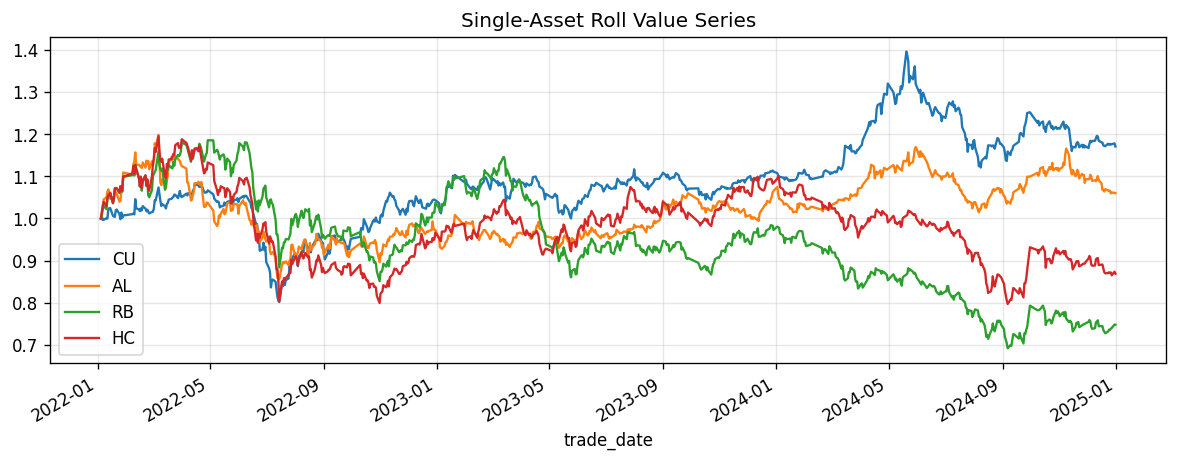

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
(price_df / price_df.iloc[0]).plot(ax=ax, lw=1.4)
ax.set_title('Single-Asset Roll Value Series')
ax.grid(alpha=0.3)
plt.show()


## 3. 先做一条最简单的时序链：`roll asset -> TSMOM -> EqualRiskSizer`

这条链说明：roll layer 产出的 `value_series` 已经可以像普通价格一样进入 signal 和 portfolio。


In [12]:
tsmom = TSMOM(60)
ts_signal_df = price_df.apply(tsmom.compute, axis=0)
roll_returns = price_df.pct_change()
vol_df = roll_returns.rolling(22).std() * np.sqrt(252)
equal_risk = EqualRiskSizer(target_vol=0.40, signal_mode='direction')
ts_weight_df = equal_risk.compute(ts_signal_df, vol_df)

display(ts_signal_df.tail())
display(ts_weight_df.tail())


,CU,AL,RB,HC
trade_date,,,,
2024-12-25,-1.0,-1.0,1.0,1.0
2024-12-26,-1.0,-1.0,1.0,1.0
2024-12-27,-1.0,-1.0,-1.0,-1.0
2024-12-30,-1.0,-1.0,-1.0,-1.0
2024-12-31,-1.0,-1.0,-1.0,-1.0


,CU,AL,RB,HC
trade_date,,,,
2024-12-25,-1.413217,-0.929985,0.774920,0.800891
2024-12-26,-1.468107,-0.921755,0.771440,0.802803
2024-12-27,-1.511097,-0.918825,-0.770505,-0.791088
2024-12-30,-1.559763,-1.059071,-0.738544,-0.759392
2024-12-31,-1.478721,-1.127364,-0.739425,-0.763204


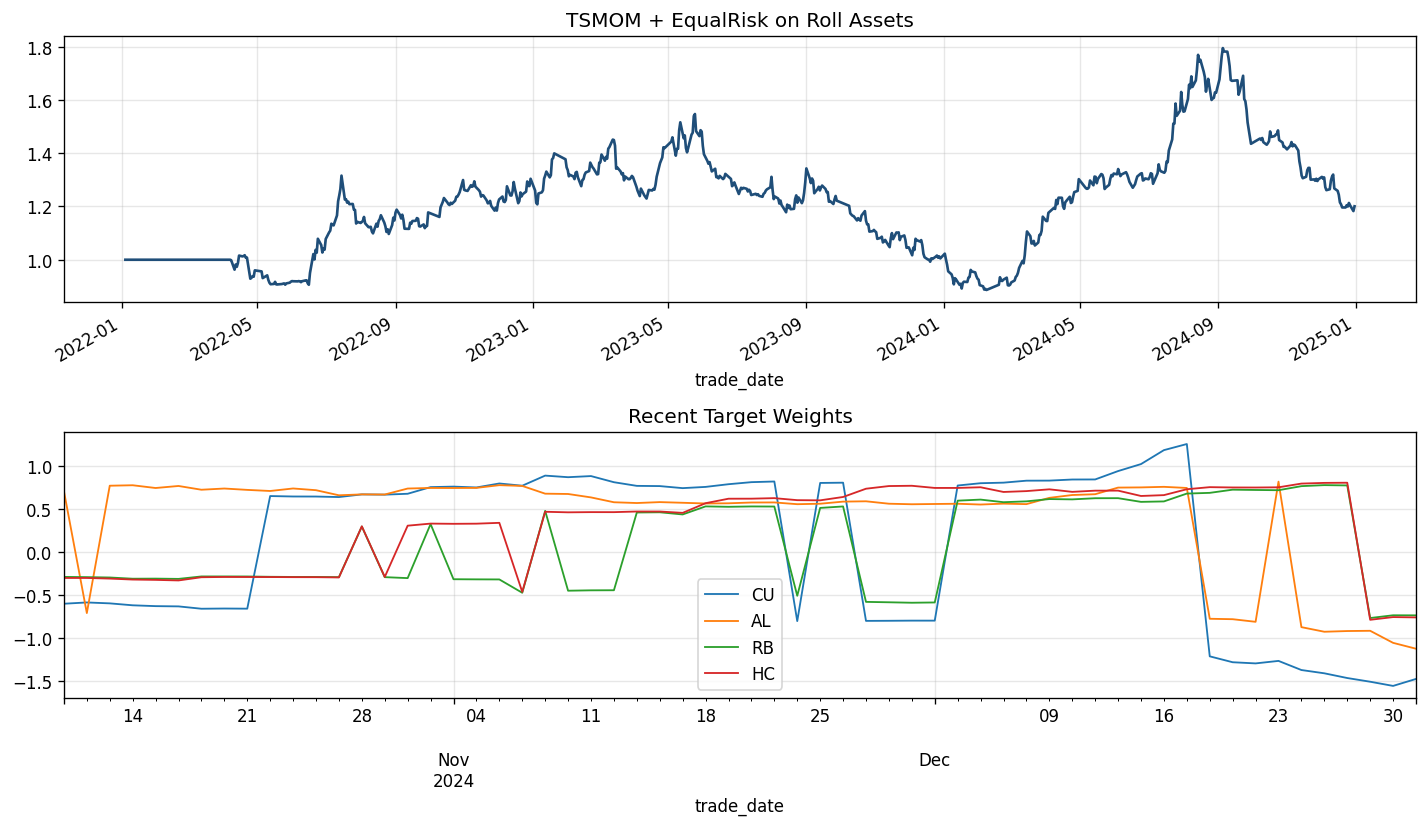

In [13]:
ts_portfolio_ret = (ts_weight_df.shift(1).fillna(0.0) * roll_returns.fillna(0.0)).sum(axis=1)
ts_nav = (1.0 + ts_portfolio_ret).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
ts_nav.plot(ax=axes[0], lw=1.6, color='#1f4e79')
axes[0].set_title('TSMOM + EqualRisk on Roll Assets')
axes[0].grid(alpha=0.3)

ts_weight_df.tail(60).plot(ax=axes[1], lw=1.1)
axes[1].set_title('Recent Target Weights')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 再做一条截面链：`roll asset -> RankCombiner -> TopBottomSelector -> RiskBudgetSizer`

这条链更接近跨资产配置。这里我们把 4 个 roll asset 当作一个小型资产池。


In [14]:
rank_score = RankCombiner([TSMOM(60)]).compute(price_df)
selector = TopBottomSelector(top_n=1, bottom_n=1)
position_intent = selector.apply(rank_score)
risk_budget = RiskBudgetSizer(base_risk=0.10, signal_mode='direction')
cs_weight_df = risk_budget.compute(position_intent, vol_df)

display(rank_score.tail())
display(position_intent.tail())
display(cs_weight_df.tail())


,CU,AL,RB,HC
trade_date,,,,
2024-12-25,0.375,0.375,0.875,0.875
2024-12-26,0.375,0.375,0.875,0.875
2024-12-27,0.625,0.625,0.625,0.625
2024-12-30,0.625,0.625,0.625,0.625
2024-12-31,0.625,0.625,0.625,0.625


,CU,AL,RB,HC
trade_date,,,,
2024-12-25,-1.0,0.0,1.0,0.0
2024-12-26,-1.0,0.0,1.0,0.0
2024-12-27,-1.0,0.0,0.0,0.0
2024-12-30,-1.0,0.0,0.0,0.0
2024-12-31,-1.0,0.0,0.0,0.0


,CU,AL,RB,HC
trade_date,,,,
2024-12-25,-0.706609,0.0,0.38746,0.0
2024-12-26,-0.734054,0.0,0.38572,0.0
2024-12-27,-1.511097,0.0,0.00000,0.0
2024-12-30,-1.559763,0.0,0.00000,0.0
2024-12-31,-1.478721,0.0,0.00000,0.0


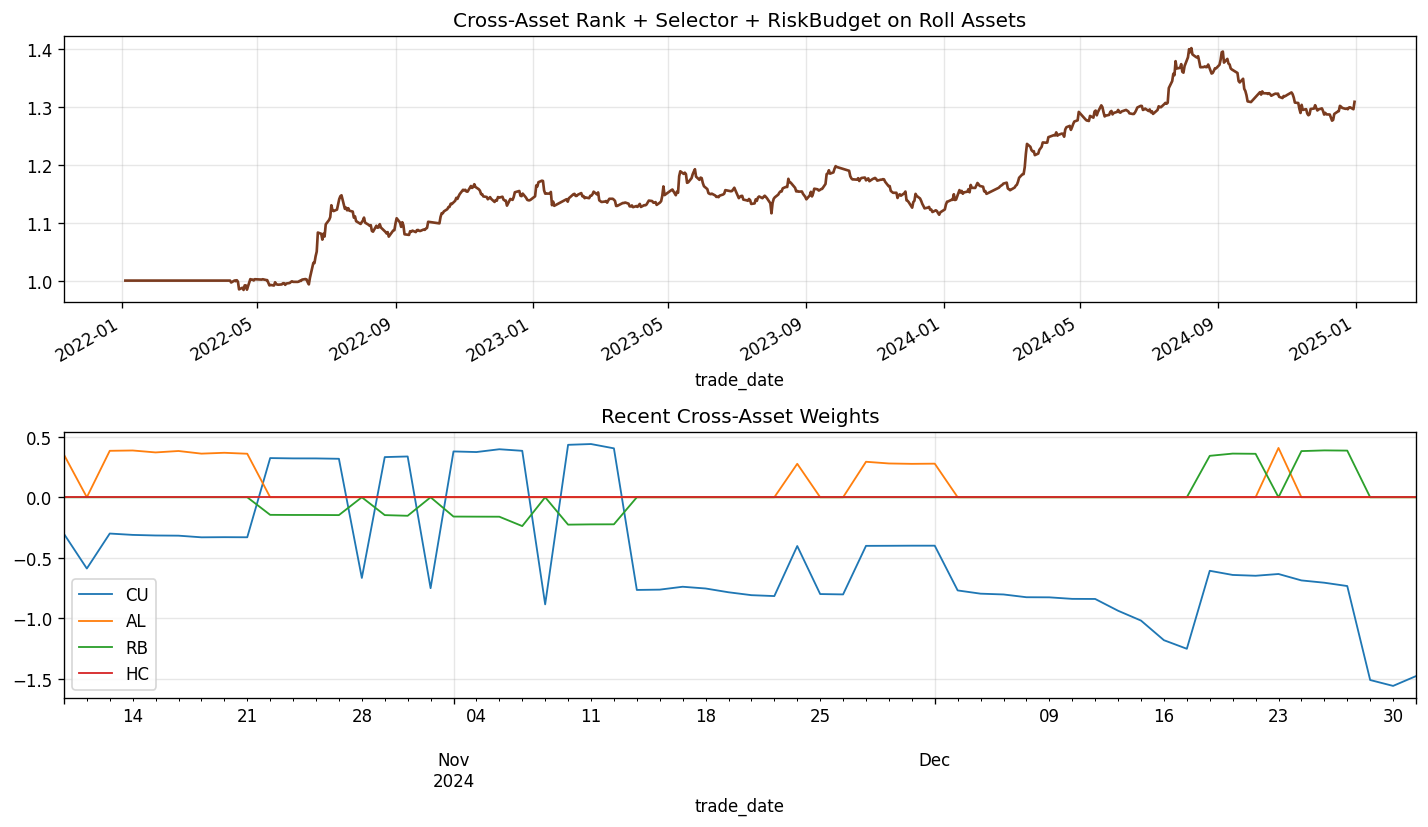

In [15]:
cs_portfolio_ret = (cs_weight_df.shift(1).fillna(0.0) * roll_returns.fillna(0.0)).sum(axis=1)
cs_nav = (1.0 + cs_portfolio_ret).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
cs_nav.plot(ax=axes[0], lw=1.6, color='#7a3b1f')
axes[0].set_title('Cross-Asset Rank + Selector + RiskBudget on Roll Assets')
axes[0].grid(alpha=0.3)

cs_weight_df.tail(60).plot(ax=axes[1], lw=1.1)
axes[1].set_title('Recent Cross-Asset Weights')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. 可选：把 bundle asset 也当成上层资产

下面用 `CU + AL` 先拼一个静态金属 bundle，再把它和 `RB / HC` 一起放进上层资产池。


In [16]:
metal_bundle_profile = RollStrategyProfile(
    name='metal_bundle',
    asset_key='METAL_BUNDLE',
    asset_mode='bundle',
    components=[
        RollComponentProfile(component_key='cu', symbol='CU'),
        RollComponentProfile(component_key='al', symbol='AL'),
    ],
    bundle_rule=BundleRule(weight_mode='static', static_weights={'cu': 0.5, 'al': 0.5}),
)
metal_bundle_result = BundleRollStrategy(metal_bundle_profile).run(
    market_data={
        'component_results': {
            'cu': single_asset_results['CU'],
            'al': single_asset_results['AL'],
        }
    }
)

bundle_pool_df = pd.DataFrame({
    'METAL_BUNDLE': metal_bundle_result.value_series,
    'RB': single_asset_results['RB'].value_series,
    'HC': single_asset_results['HC'].value_series,
}).sort_index()
bundle_pool_df.tail()


,METAL_BUNDLE,RB,HC
trade_date,,,
2024-12-25,1.129243,0.735652,0.870952
2024-12-26,1.125149,0.738369,0.871980
2024-12-27,1.126601,0.740181,0.865296
2024-12-30,1.127375,0.748258,0.873580
2024-12-31,1.123190,0.747962,0.869064


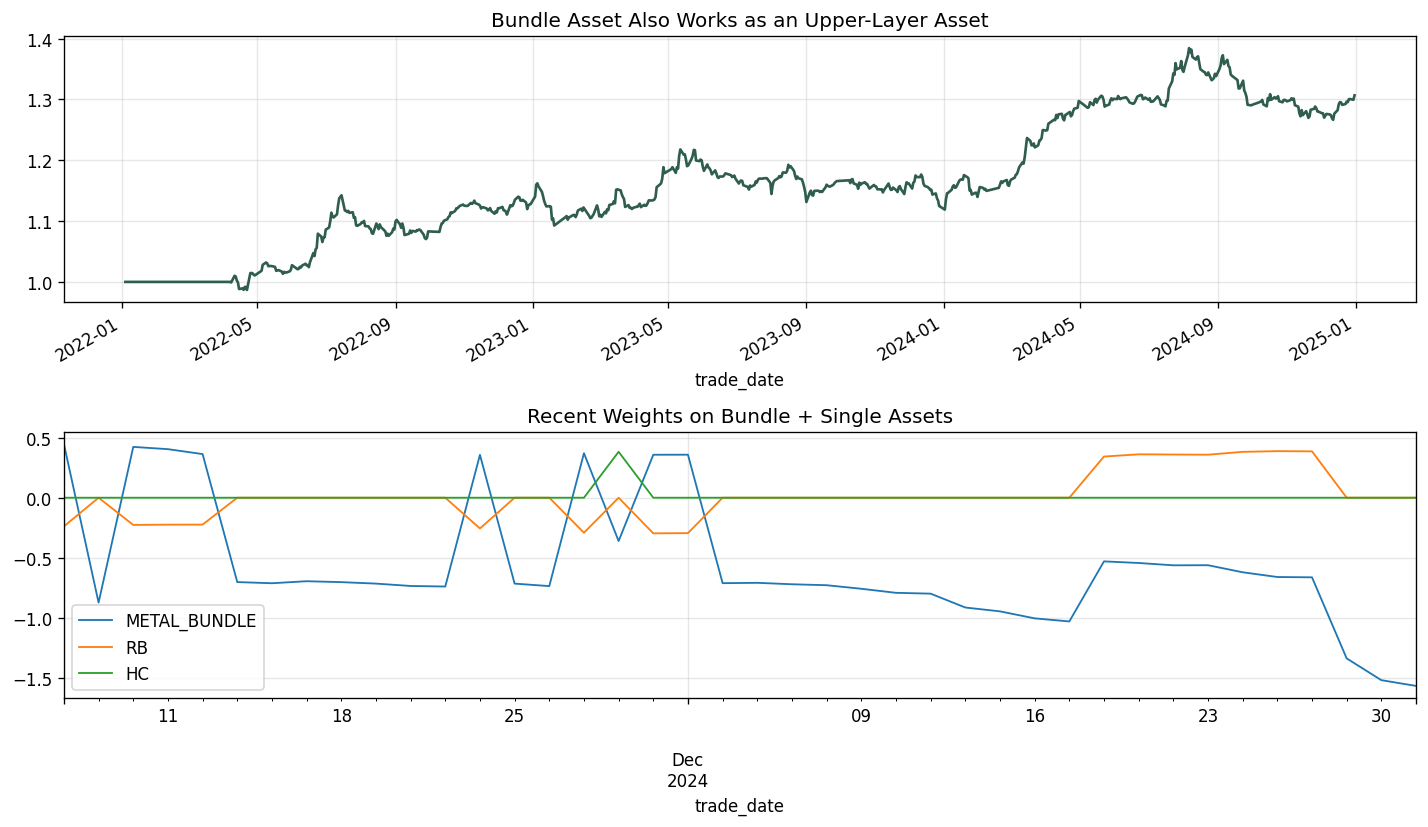

In [17]:
bundle_rank_score = RankCombiner([TSMOM(60)]).compute(bundle_pool_df)
bundle_positions = TopBottomSelector(top_n=1, bottom_n=1).apply(bundle_rank_score)
bundle_returns = bundle_pool_df.pct_change()
bundle_vol = bundle_returns.rolling(22).std() * np.sqrt(252)
bundle_weights = RiskBudgetSizer(base_risk=0.10).compute(bundle_positions, bundle_vol)
bundle_nav = (1.0 + (bundle_weights.shift(1).fillna(0.0) * bundle_returns.fillna(0.0)).sum(axis=1)).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
bundle_nav.plot(ax=axes[0], lw=1.6, color='#2f5d50')
axes[0].set_title('Bundle Asset Also Works as an Upper-Layer Asset')
axes[0].grid(alpha=0.3)

bundle_weights.tail(40).plot(ax=axes[1], lw=1.1)
axes[1].set_title('Recent Weights on Bundle + Single Assets')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. 小结

这份 notebook 主要验证了 3 件事：

1. single-asset roll 生成的 `value_series` 已经可以直接视作上层 `signals` 的价格输入。
2. 这些 roll asset 既可以进入时序信号链，也可以进入截面配置链。
3. bundle asset 本身也可以继续作为更上层的资产，被 `signals/portfolio` 再次消费。

这说明 `roll layer` 已经不只是一个底层技术组件，而开始成为可进入上层 CTA 研究流程的资产生成层。
